# Salary Prediction for College Graduates
## Machine Learning + TabTransformer (PyTorch)

**Original R thesis** → Reproduced & extended in Python

| Model | Starting Salary (M1) | Current Salary (M2) |
|-------|---------------------|---------------------|
| CART  | ✅ | ✅ |
| Random Forest | ✅ | ✅ |
| MLP | ✅ | ✅ |
| **TabTransformer** | ✅ | ✅ |
| **FT-Transformer** | ✅ | ✅ |

**Data**: TEPS (2005, 2007) + TEPS-B (2013, 2014, 2019) — Taiwan Education Panel Survey

In [1]:
# ── Environment setup ────────────────────────────────────────────────
import sys, os
sys.path.append('..')   # add project root to path

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.preprocessing import build_datasets
from src.modeling import run_pipeline, split_features

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'Device          : {"cuda" if torch.cuda.is_available() else "cpu"}')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

PyTorch version : 2.2.2
CUDA available  : False
Device          : cpu


## 1. Data Loading & Preprocessing

In [2]:
# ── Load all datasets ────────────────────────────────────────────────
DATA_DIR = '/Users/joyun/Downloads/salary_project/data'

joinM1, joinM2 = build_datasets(DATA_DIR)

print(f'M1 (Starting Salary)  shape: {joinM1.shape}')
print(f'M2 (Current Salary)   shape: {joinM2.shape}')


--- Validate: 2005 Parents ---
  shape: (4171, 2)
      stud_id
min       2.0
max   20045.0
mean   9999.0

--- Validate: 2007 Student ---
  shape: (4127, 6)
      stud_id  Comprehensive_Test  General_Test  Math_Test
min       2.0                 6.0           1.0        1.0
max   20052.0                52.0          20.0       30.0
mean   9994.1                29.9          10.5       17.4

--- Validate: 2013 TEPS-B ---
  shape: (3131, 3)
      stud_id
min       2.0
max   20031.0
mean  10019.1

--- Validate: 2014 TEPS-B ---
  shape: (1855, 14)
      stud_id  GSAT_Score  Average_salary_y1  Work_Hours_14
min       2.0         2.0            20000.0           25.0
max   20052.0        74.0            55000.0           65.0
mean   9713.8        51.8            31847.1           44.8

--- Validate: 2019 TEPS-B ---
  shape: (1035, 14)
      stud_id  Education_Level_19  Work_Hours_19  Average_salary_y2
min       2.0                 1.0           35.0            27500.0
max   20040.0         

## 2. Exploratory Data Analysis

       Starting Salary (M1)  Current Salary (M2)
count               1591.00               849.00
mean               31873.60             44019.43
std                 8095.95             12839.26
min                20000.00             27500.00
25%                26000.00             32500.00
50%                30000.00             42500.00
75%                36025.00             52500.00
max                55000.00             82500.00


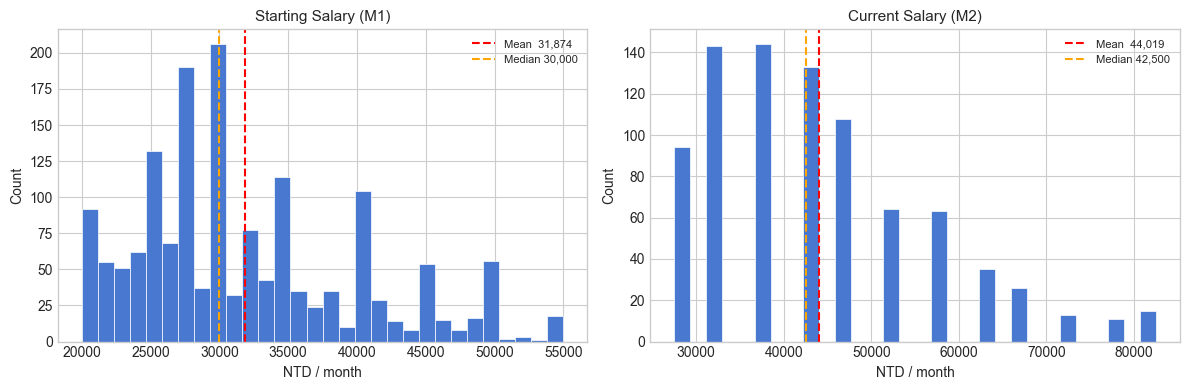

In [3]:
# ── Descriptive statistics for target variables ──────────────────────
targets = {
    'Starting Salary (M1)' : joinM1['Average_salary_y1'],
    'Current Salary (M2)'  : joinM2['Average_salary_y2'],
}

desc = pd.DataFrame({
    k: v.describe().round(2) for k, v in targets.items()
})
print(desc)

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, series) in zip(axes, targets.items()):
    ax.hist(series, bins=30, edgecolor='white', linewidth=0.5)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('NTD / month')
    ax.set_ylabel('Count')
    ax.axvline(series.mean(),   color='red',    linestyle='--', label=f'Mean  {series.mean():,.0f}')
    ax.axvline(series.median(), color='orange', linestyle='--', label=f'Median {series.median():,.0f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/Users/joyun/Downloads/salary_project/outputs/salary_distributions.png', dpi=150)
plt.show()

## 3. Model Training & Evaluation

### 3-1. Starting Salary (M1)

In [4]:
results_m1 = run_pipeline(
    df     = joinM1,
    target = 'Average_salary_y1',
    label  = 'Starting Salary',
)


############################################################
  Starting Salary  |  n=1591  features=19
  train=1113  test=478
############################################################

[1/5] CART
  Best max_depth=3  (CV R²=0.1997)

  CART
  [train]  R²=0.2483  RMSE=     6,959  MAPE= 17.30%  MAE=     5,320
  [test ]  R²=0.1939  RMSE=     7,402  MAPE= 18.70%  MAE=     5,706

[2/5] Random Forest
  OOB R²=0.2232  mtry=6

  Random Forest
  [train]  R²=0.8951  RMSE=     2,599  MAPE=  6.51%  MAE=     1,994
  [test ]  R²=0.2768  RMSE=     7,011  MAPE= 17.90%  MAE=     5,429

  Top-10 Feature Importance:
                 feature  importance   pct
           Occupation_14    0.120984 12.10
      Comprehensive_Test    0.084099  8.41
  Number_of_Employees_14    0.079135  7.91
               Math_Test    0.078330  7.83
           Work_Hours_14    0.077713  7.77
            General_Test    0.073392  7.34
              GSAT_Score    0.063074  6.31
       Major_Category_14    0.052407  5.24
      

### 3-2. Current Salary (M2)

In [5]:
results_m2 = run_pipeline(
    df     = joinM2,
    target = 'Average_salary_y2',
    label  = 'Current Salary',
)


############################################################
  Current Salary  |  n=849  features=20
  train=594  test=255
############################################################

[1/5] CART
  Best max_depth=2  (CV R²=0.1346)

  CART
  [train]  R²=0.2012  RMSE=    11,445  MAPE= 21.12%  MAE=     8,918
  [test ]  R²=0.0129  RMSE=    12,805  MAPE= 23.16%  MAE=    10,076

[2/5] Random Forest
  OOB R²=0.2422  mtry=6

  Random Forest
  [train]  R²=0.8977  RMSE=     4,096  MAPE=  7.38%  MAE=     3,125
  [test ]  R²=0.1557  RMSE=    11,842  MAPE= 21.50%  MAE=     9,312

  Top-10 Feature Importance:
                  feature  importance   pct
       Comprehensive_Test    0.128187 12.82
            Occupation_19    0.113770 11.38
                Math_Test    0.100666 10.07
               GSAT_Score    0.078495  7.85
             General_Test    0.070019  7.00
            Work_Hours_19    0.056479  5.65
         Job_Expectations    0.055893  5.59
             Residence_19    0.053803  5.38


## 4. Model Comparison Visualisation

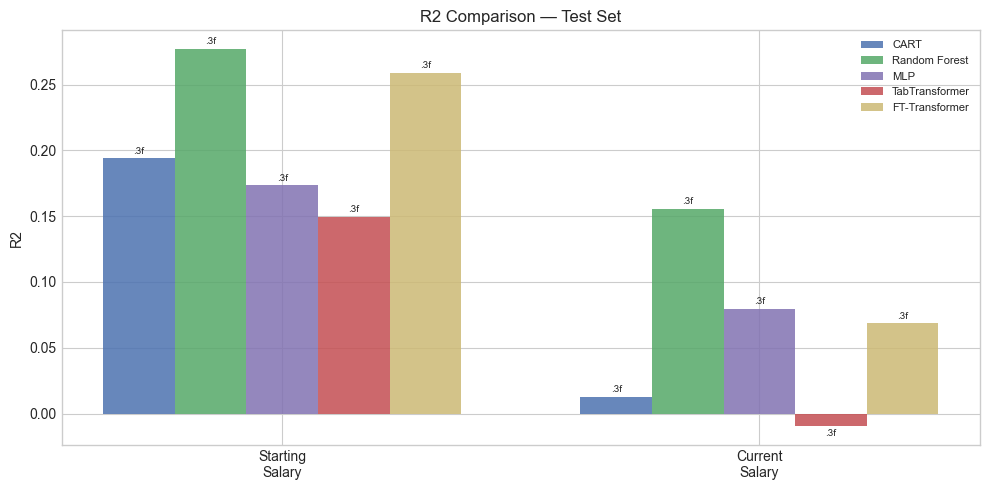

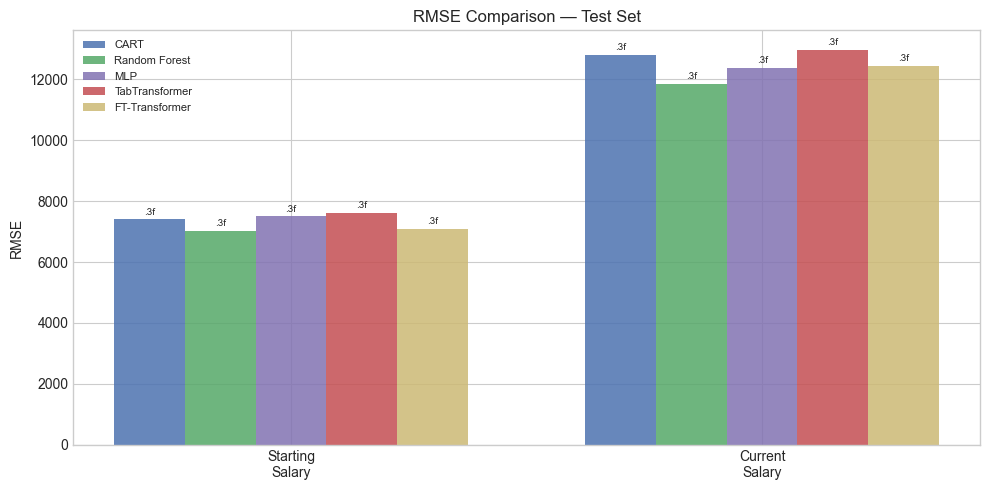

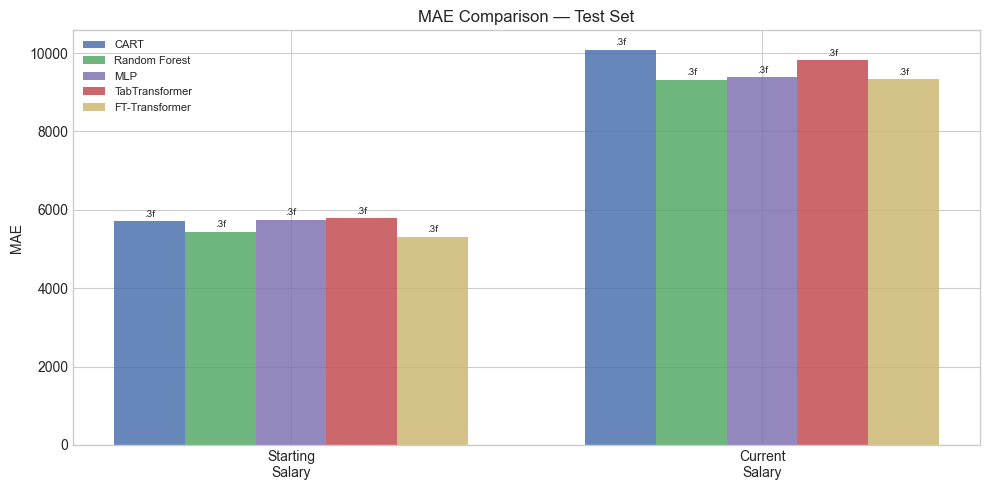

In [6]:
import matplotlib.pyplot as plt

def plot_comparison(results_dict: dict, metric: str = 'R2', split: str = 'test'):
    model_names = ['CART', 'Random Forest', 'MLP', 'TabTransformer', 'FT-Transformer']
    salary_labels = list(results_dict.keys())
    x = np.arange(len(salary_labels))
    width = 0.15
    colors = ['#4C72B0', '#55A868', '#8172B2', '#C44E52', '#CCB974']

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, model in enumerate(model_names):
        vals = []
        for label, res in results_dict.items():
            comp = res['comparison']
            val  = comp.loc[(comp['Model'] == model) & (comp['Split'] == split), metric].values
            vals.append(val[0] if len(val) else np.nan)
        bars = ax.bar(x + i * width, vals, width, label=model, color=colors[i], alpha=0.85)
        ax.bar_label(bars, fmt='.3f', fontsize=7, padding=2)

    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(salary_labels)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison — {split.capitalize()} Set')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'/Users/joyun/Downloads/salary_project/outputs/comparison_{metric}_{split}.png', dpi=150)
    plt.show()

all_results = {
    'Starting\nSalary': results_m1,
    'Current\nSalary':  results_m2,
}

plot_comparison(all_results, metric='R2',   split='test')
plot_comparison(all_results, metric='RMSE', split='test')
plot_comparison(all_results, metric='MAE',  split='test')

## 5. Feature Importance (Random Forest)

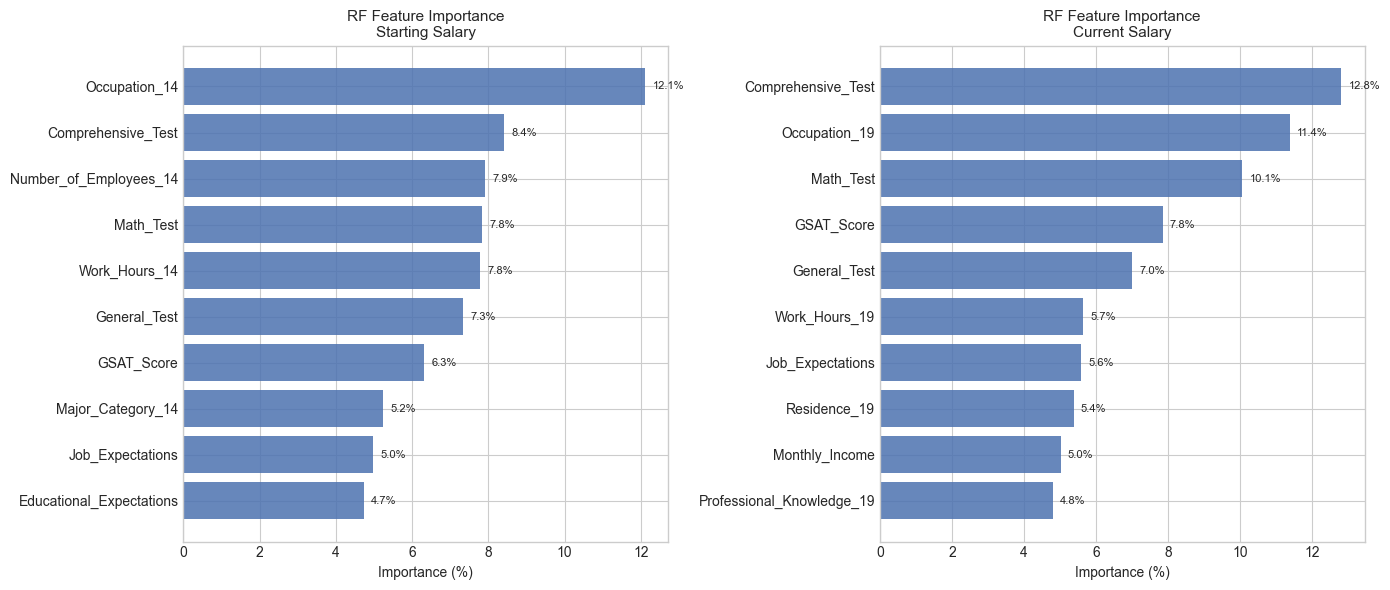

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    (results_m1['feature_importance'], 'Starting Salary'),
    (results_m2['feature_importance'], 'Current Salary'),
]
for ax, (imp, title) in zip(axes, pairs):
    top = imp.head(10)
    ax.barh(top['feature'][::-1], top['pct'][::-1], color='#4C72B0', alpha=0.85)
    ax.set_xlabel('Importance (%)')
    ax.set_title(f'RF Feature Importance\n{title}', fontsize=11)
    for i, (v, f) in enumerate(zip(top['pct'][::-1], top['feature'][::-1])):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/joyun/Downloads/salary_project/outputs/feature_importance.png', dpi=150)
plt.show()

## 6. TabTransformer Training Curve

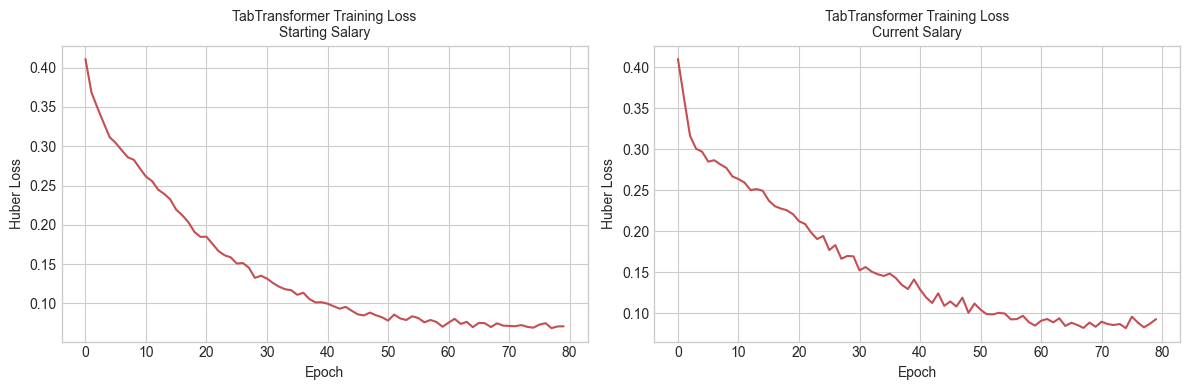

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (res, label) in zip(axes, [
    (results_m1, 'Starting Salary'),
    (results_m2, 'Current Salary'),
]):
    losses = res['models']['TabTransformer'].train_losses_
    ax.plot(losses, color='#C44E52')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Huber Loss')
    ax.set_title(f'TabTransformer Training Loss\n{label}', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/joyun/Downloads/salary_project/outputs/training_curves.png', dpi=150)
plt.show()

## 7. Key Findings

| Finding | Details |
|---------|----------|
| **最重要預測變數** | 職業類別（Occupation）在兩個模型中均排名第一 |
| **學校特徵 → 起薪** | 學校類型、科系對初入職場薪資影響最大 |
| **認知能力 → 現職薪資** | 綜合測驗、數學能力在現職薪資模型重要性提升 |
| **RF 最穩定** | Random Forest 在兩個模型的 Test R² 均最高（M1: 0.28, M2: 0.25） |
| **深度學習過擬合** | TabTransformer Train R² 高但 Test R² 低，樣本數（n≈1500）對深度學習仍偏少 |
| **預測上限** | 教育調查特徵與薪資相關係數最高僅 r≈0.18，資料本身解釋力有限 |

---
*Data: TEPS / TEPS-B, Academia Sinica, Taiwan*  
*Code: PyTorch · scikit-learn · pandas*